In [1]:
# Install RAPIDS cuML
# This command is specific for Colab and installs the necessary packages for GPU acceleration.
!pip install cuml-cu12 --extra-index-url https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 36.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 70.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 MB 113.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.1/338.1 MB 72.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.5/366.5 MB 78.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 170.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 148.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cusparse-cu12
    Found existing installation: nvidia-cusparse-cu12 12.5.4.2
    Uninstalling nvidia-cusparse-cu12-12.5.4.2:
      Successfully uninstalled nvidia-cusparse-cu12-12.5.4.2
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.7.77
    Uninstalling nvidia-curand-cu12-10.3.7

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os
#os.chdir('c:/py/data')
os.chdir('/content/drive/MyDrive/repo/Lexi') #<-- your local
print(os.getcwd())

/content/drive/MyDrive/repo/Lexi


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [5]:
historical = pd.read_csv('race_predictions.csv', header=0, encoding='utf-8', sep=',')
formdata = pd.read_csv('form data.csv', header=0, encoding='utf-8', sep=',')

historical.head()
print(historical.columns)
print(f"Total number of rows in historical: {historical.shape[0]}")
#formdata.head()

/tmp/ipython-input-3523356083.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  historical = pd.read_csv('race_predictions.csv', header=0, encoding='utf-8', sep=',')


Index(['Key', 'date', 'time', 'track', 'race_number', 'Field Size', 'Places',
       'horse_number', 'horse_name', 'lexi_tip_line', 'Rank Change',
       'morning_odds', 'race_time_odds', 'sp_odds', 'Place Odds', 'result',
       'won_flag', 'placed_flag', 'outsider_flag', 'outsider_win_flag',
       'SCRATCHED', 'Strategy Qualified', 'Strategy Stake T1',
       'Strategy Stake T2', 'Strategy Stake T3', 'Strategy Stake T4',
       'Strategy Total Stake', 'Strategy Target Return', 'Strategy Return',
       'Strategy Profit', 'Strategy ROI', 'Strategy Comment'],
      dtype='object')
Total number of rows in historical: 109930


In [6]:
rows = historical.shape[0]

features = ['track', 'race_number', 'Field Size', 'Places', 'horse_name', 'Rank Change', 'morning_odds', 'race_time_odds', 'sp_odds', 'Place Odds', 'outsider_flag']
targets = ['won_flag']

feature_inds = [historical.columns.get_loc(col) for col in features]
target_inds = [historical.columns.get_loc(col) for col in targets]

X = historical.iloc[0:rows, feature_inds].values
y = historical.iloc[0:rows, target_inds].values

# Add X_Geelong variable
track_column_index_in_X = features.index('track')
X_Geelong = X[X[:, track_column_index_in_X] == 'Geelong']
y_Geelong = y[X[:, track_column_index_in_X] == 'Geelong']

In [7]:
import sys
import numpy as np

# Set print options to display the full array without truncation
np.set_printoptions(threshold=sys.maxsize, linewidth=sys.maxsize)

# Print X again with the new print options
#print(X)

In [8]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (75% train, 25% test)
#X_train, X_test, y_train, y_test = train_test_split(X_Geelong, y_Geelong, test_size=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (82447, 11)
X_test shape: (27483, 11)
y_train shape: (82447, 1)
y_test shape: (27483, 1)


RAM

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, matthews_corrcoef
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Import cuml's RandomForestClassifier
from cuml.ensemble import RandomForestClassifier

# Identify categorical features by their indices in the X array
# Based on the 'features' list: ['track', 'race_number', 'Field Size', 'Places', 'horse_name', 'Rank Change', 'morning_odds', 'race_time_odds', 'sp_odds', 'Place Odds', 'outsider_flag']
# The string columns are at indices 0 (track), 4 (horse_name), and 5 (Rank Change)
categorical_features_indices = [0, 4, 5]

# Identify numerical features (all others)
all_feature_indices = list(range(X_train.shape[1]))
numerical_features_indices = [i for i in all_feature_indices if i not in categorical_features_indices]

# Create a ColumnTransformer to apply different preprocessing steps to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_indices),
        ('num', SimpleImputer(strategy='mean'), numerical_features_indices) # Impute missing numerical values
    ],
    remainder='passthrough' # Keep any other columns as they are (though there shouldn't be any if all are covered)
)

# Apply the preprocessing to X_train and X_test
# Convert sparse output to dense array using .toarray() as cuML does not support sparse inputs
# Convert to float32 to reduce memory footprint on GPU
X_train_processed = preprocessor.fit_transform(X_train).toarray().astype('float32')
X_test_processed = preprocessor.transform(X_test).toarray().astype('float32')

# Initialize the Random Forest Classifier from cuML
# Setting n_estimators to 10 and min_samples_split to 5 as requested
rf_classifier = RandomForestClassifier(n_estimators=10, min_samples_split=5, random_state=42)

# Train the model using the processed training data
rf_classifier.fit(X_train_processed, y_train.ravel()) # .ravel() is used to convert y_train from (n, 1) to (n,)

# Make predictions on the processed test data
y_pred_cuml = rf_classifier.predict(X_test_processed)
y_pred_proba_cuml = rf_classifier.predict_proba(X_test_processed)[:, 1] # Get probabilities for the positive class

# Convert cuML outputs to NumPy arrays for compatibility with scikit-learn metrics and subsequent cells
y_pred = y_pred_cuml.to_numpy()
y_pred_proba = y_pred_proba_cuml.to_numpy()

# Evaluate the model
print("Random Forest Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Calculate and print AUC and MCC
print("AUC: ", roc_auc_score(y_test, y_pred_proba))
print("MCC: ", matthews_corrcoef(y_test, y_pred))

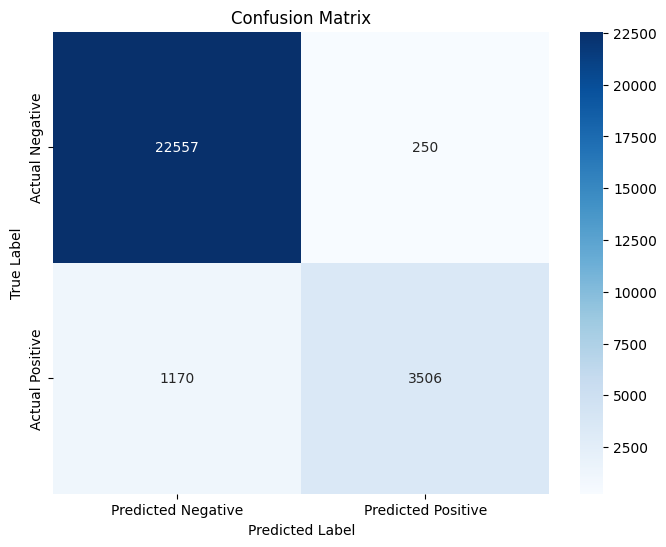

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Switching to GPU Runtime and Using cuML

To utilize a GPU, you must first change your Colab notebook's runtime type:

1.  Go to `Runtime` in the Colab menu.
2.  Select `Change runtime type`.
3.  In the dialog, choose `GPU` as the `Hardware accelerator`.
4.  Click `Save`.

After switching to a GPU runtime, you can install `cuML`, a GPU-accelerated machine learning library from the RAPIDS suite, which offers scikit-learn-like APIs for many algorithms, including Random Forest.

### Adapting the Random Forest Model to use cuML

Once `cuML` is installed and you are on a GPU runtime, you can modify your model training cell to use `cuml.ensemble.RandomForestClassifier`. The API is designed to be very similar to scikit-learn's equivalent.

**Note**: For optimal performance with `cuML`, it's often beneficial to convert your data (X_train_processed, y_train) to GPU-compatible formats like `cupy` arrays or `cudf` DataFrames, especially for larger datasets. However, `cuml` can often handle NumPy arrays directly, moving them to GPU internally. For this example, we'll primarily focus on replacing the scikit-learn import with the `cuml` import.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the new input data
input_data = pd.read_csv('input-rr.csv', header=0, encoding='utf-8', sep=',')

# Ensure the input data has the same features in the same order
# as used for training (defined in the 'features' list earlier)
X_new = input_data[features].values

# Preprocess the new input features using the already fitted preprocessor
X_new_processed = preprocessor.transform(X_new)

# Make predictions using the trained Random Forest model (now cuML's)
y_new_pred_cuml = rf_classifier.predict(X_new_processed)
y_new_pred_proba_cuml = rf_classifier.predict_proba(X_new_processed)[:, 1] # Probability of winning

# Convert cuML outputs to NumPy arrays
y_new_pred = y_new_pred_cuml.to_numpy()
y_new_pred_proba = y_new_pred_proba_cuml.to_numpy()

print("Predictions for new input data (won_flag):")
print(y_new_pred)
print("\nPrediction probabilities for new input data (winning chance):")
print(y_new_pred_proba)

# Add predictions to the input_data DataFrame for easy filtering
input_data['predicted_won_flag'] = y_new_pred
input_data['prediction_probability'] = y_new_pred_proba

# Filter for predictions where won_flag is 1
winning_predictions = input_data[input_data['predicted_won_flag'] == 1]

# Check if the original 'won_flag' column exists in the input data
include_actual_won_flag = 'won_flag' in input_data.columns

# Sort winning predictions by probability in descending order
winning_predictions = winning_predictions.sort_values(by='prediction_probability', ascending=False)

# Print the desired columns for winning predictions in a formatted way
print("\n--- Details for Predicted Winning Horses ---")
if not winning_predictions.empty:
    # Define columns and their display widths
    cols = ['Date', 'Track', 'Race #', 'Horse Name', 'Probability']
    widths = [12, 18, 8, 28, 12]

    if include_actual_won_flag:
        cols.append('Actual Won')
        widths.append(12)

    header_format = " ".join([f"{{:<{w}}}" for w in widths])
    print(header_format.format(*cols))
    print("-" * sum(widths + [len(cols) - 1])) # Separator line

    for index, row in winning_predictions.iterrows():
        output_values = [
            row['date'],
            row['track'],
            str(row['race_number']),
            row['horse_name'],
            f"{row['prediction_probability']:.2f}"
        ]
        if include_actual_won_flag:
            output_values.append(str(row['won_flag']))
        print(header_format.format(*output_values))
else:
    print("No predicted winning horses found.")

# Provide a summary of accuracy if 'won_flag' (actual) is available in input_data
if include_actual_won_flag:
    print("\n--- Prediction Accuracy Summary ---")
    y_true_all = input_data['won_flag'].values
    y_pred_all = input_data['predicted_won_flag'].values

    overall_accuracy = accuracy_score(y_true_all, y_pred_all)
    overall_precision = precision_score(y_true_all, y_pred_all, zero_division=0) # Handle cases with no positive predictions
    overall_recall = recall_score(y_true_all, y_pred_all, zero_division=0)
    overall_f1 = f1_score(y_true_all, y_pred_all, zero_division=0)

    print(f"Total Number of Predictions: {len(y_true_all)}")
    print(f"Number of Actual Wins: {y_true_all.sum()}")
    print(f"Number of Predicted Wins: {y_pred_all.sum()}")
    print(f"Overall Accuracy: {overall_accuracy:.4f}")
    print(f"Overall Precision: {overall_precision:.4f}")
    print(f"Overall Recall: {overall_recall:.4f}")
    print(f"Overall F1-Score: {overall_f1:.4f}")

Predictions for new input data (won_flag):
[1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0]

Prediction probabilities for new input data (winning chance):
[0.61833333 0.03428571 0.         0.         0.         0.         0.21666667 0.         0.8        0.         0.06166667 0.         0.         0.         0.         0.         0.         0.13666667 0.225